In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

RAW       = Path(os.getcwd())
PROCESSED = RAW / "processed"

df_nav  = pd.read_csv(PROCESSED / "clean_nav.csv",          parse_dates=["date"])
df_fund = pd.read_csv(PROCESSED / "clean_fund_master.csv")
df_txn  = pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=["transaction_date"])
df_hold = pd.read_csv(PROCESSED / "clean_holdings.csv")
df_perf = pd.read_csv(PROCESSED / "clean_performance.csv")

print("Data loaded!")

Data loaded!


In [2]:
results = []

for code, group in df_nav.groupby("amfi_code"):
    returns = group["daily_return_pct"].dropna()

    if len(returns) < 30:
        continue

    # VaR = worst 5% of daily returns
    var  = np.percentile(returns, 5)

    # CVaR = average of those worst days
    cvar = returns[returns <= var].mean()

    results.append({
        "amfi_code":   code,
        "var_95_pct":  round(var, 2),
        "cvar_95_pct": round(cvar, 2)
    })

df_var = pd.DataFrame(results)
df_var = df_var.merge(df_fund[["amfi_code", "scheme_name"]], on="amfi_code")

# Show riskiest funds
print("Most Risky Funds:")
print(df_var.sort_values("var_95_pct").head(5)[["scheme_name", "var_95_pct", "cvar_95_pct"]])

df_var.to_csv(PROCESSED / "var_cvar_report.csv", index=False)
print("Saved!")

Most Risky Funds:
                                       scheme_name  var_95_pct  cvar_95_pct
22       SBI Small Cap Fund - Direct Plan - Growth       -2.69        -3.24
17          Axis Small Cap Fund - Regular - Growth       -2.62        -3.17
4           ABSL Small Cap Fund - Regular - Growth       -2.60        -3.25
11  Nippon India Small Cap Fund - Regular - Growth       -2.54        -3.23
21      SBI Small Cap Fund - Regular Plan - Growth       -2.45        -3.06
Saved!


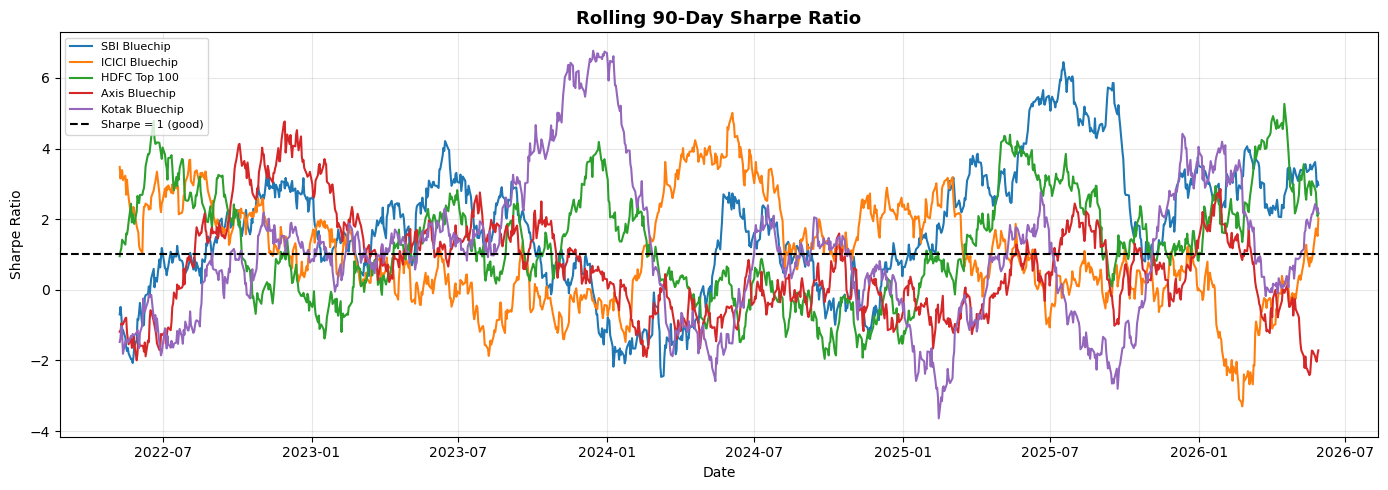

Saved rolling_sharpe_chart.png


In [3]:
# 5 funds to plot
funds = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    125497: "HDFC Top 100",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

plt.figure(figsize=(14, 5))

for code, name in funds.items():
    
    df_one = df_nav[df_nav["amfi_code"] == code].sort_values("date").copy()
    returns = df_one["daily_return_pct"] / 100

    roll_mean = returns.rolling(90).mean()
    roll_std  = returns.rolling(90).std()
    sharpe    = (roll_mean / roll_std) * np.sqrt(252)

    plt.plot(df_one["date"], sharpe, label=name)

plt.axhline(y=1, color="black", linestyle="--", label="Sharpe = 1 (good)")
plt.title("Rolling 90-Day Sharpe Ratio", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RAW / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Saved rolling_sharpe_chart.png")

=== Cohort Summary ===
   cohort_year  investors  avg_sip  total_amount_cr
0         2024       4624  10997.0            21.50
1         2025        138  13505.0             0.23


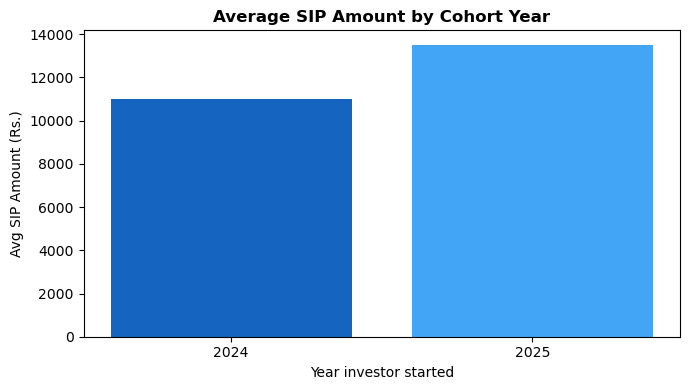

In [4]:
# Find each investor's first transaction year
first_txn = df_txn.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

df_txn = df_txn.merge(first_txn[["investor_id", "cohort_year"]], on="investor_id")


sip = df_txn[df_txn["transaction_type"] == "Sip"]


summary = sip.groupby("cohort_year").agg(
    investors    = ("investor_id", "nunique"),
    avg_sip      = ("amount_inr", "mean"),
    total_amount = ("amount_inr", "sum")
).reset_index()

summary["avg_sip"]          = summary["avg_sip"].round(0)
summary["total_amount_cr"]  = (summary["total_amount"] / 1e7).round(2)

print("=== Cohort Summary ===")
print(summary[["cohort_year", "investors", "avg_sip", "total_amount_cr"]])

summary.to_csv(PROCESSED / "cohort_analysis.csv", index=False)

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(summary["cohort_year"].astype(str), summary["avg_sip"], color=["#1565C0", "#42A5F5", "#90CAF9"])
plt.title("Average SIP Amount by Cohort Year", fontweight="bold")
plt.xlabel("Year investor started")
plt.ylabel("Avg SIP Amount (Rs.)")
plt.tight_layout()
plt.savefig(RAW / "cohort_chart.png", dpi=150)
plt.show()

=== SIP Continuity ===
status
At Risk    1332
Regular      30
Name: count, dtype: int64


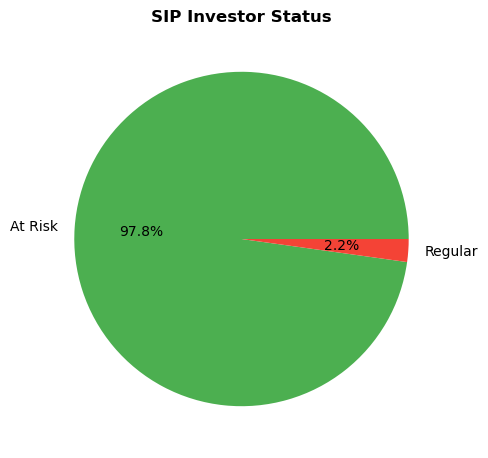

In [5]:
# investors who skip SIP payments (gap > 35 days) and flag them as "At Risk"
# SIP transactions sorted by investor and date
sip = df_txn[df_txn["transaction_type"] == "Sip"].sort_values(["investor_id", "transaction_date"])

# Gap between consecutive SIPs for same investor
sip["prev_date"] = sip.groupby("investor_id")["transaction_date"].shift(1)
sip["gap_days"]  = (sip["transaction_date"] - sip["prev_date"]).dt.days

# Only investors with 6+ SIPs
counts    = sip.groupby("investor_id").size()
active    = counts[counts >= 6].index
sip_active = sip[sip["investor_id"].isin(active)]

# Average gap per investor
result = sip_active.groupby("investor_id")["gap_days"].mean().reset_index()
result.columns = ["investor_id", "avg_gap_days"]

# Flag at-risk
result["status"] = result["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

print("=== SIP Continuity ===")
print(result["status"].value_counts())

result.to_csv(PROCESSED / "sip_continuity.csv", index=False)

# Pie chart
counts = result["status"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(counts.values, labels=counts.index,
        autopct="%1.1f%%", colors=["#4CAF50", "#F44336"])
plt.title("SIP Investor Status", fontweight="bold")
plt.tight_layout()
plt.savefig(RAW / "sip_continuity_chart.png", dpi=150)
plt.show()

In [6]:
#Simple function that takes investor risk level and returns top 3 funds
def recommend(risk):
    # Map risk level to fund grades
    if risk == "Low":
        grades = ["Low", "Moderate"]
    elif risk == "Moderate":
        grades = ["Moderate"]
    else:
        grades = ["High", "Very High"]

    # Filter and pick top 3 by sharpe ratio
    filtered = df_perf[df_perf["risk_grade"].isin(grades)]
    top3     = filtered.nlargest(3, "sharpe_ratio")[
        ["scheme_name", "sharpe_ratio", "return_3yr_pct"]
    ]

    print(f"\nTop 3 funds for {risk} risk investor:")
    print(top3.to_string(index=False))

# Try all 3 types
recommend("Low")
recommend("Moderate")
recommend("High")


Top 3 funds for Low risk investor:
                             scheme_name  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth          7.68            7.68
    Kotak Liquid Fund - Regular - Growth          6.18            6.18
     ABSL Liquid Fund - Regular - Growth          5.14            5.14

Top 3 funds for Moderate risk investor:
                                  scheme_name  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth          1.03           14.41

Top 3 funds for High risk investor:
                                  scheme_name  sharpe_ratio  return_3yr_pct
Kotak Emerging Equity Fund - Regular - Growth          0.96           18.23
     ICICI Pru Midcap Fund - Regular - Growth          0.95           18.08
   SBI Small Cap Fund - Regular Plan - Growth          0.94           

=== Most Concentrated Funds ===
                                          scheme_name     hhi
11              Axis Bluechip Fund - Regular - Growth  0.2064
3              ABSL Small Cap Fund - Regular - Growth  0.2007
18          SBI Small Cap Fund - Direct Plan - Growth  0.1748
4          UTI Nifty 50 Index Fund - Regular - Growth  0.1747
7      Nippon India Large Cap Fund - Regular - Growth  0.1683
29  Mirae Asset Emerging Bluechip Fund - Regular -...  0.1679
21           ICICI Pru Midcap Fund - Regular - Growth  0.1576
22  ICICI Pru Value Discovery Fund - Regular - Growth  0.1538
27  HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.1524
23             Kotak Bluechip Fund - Regular - Growth  0.1497


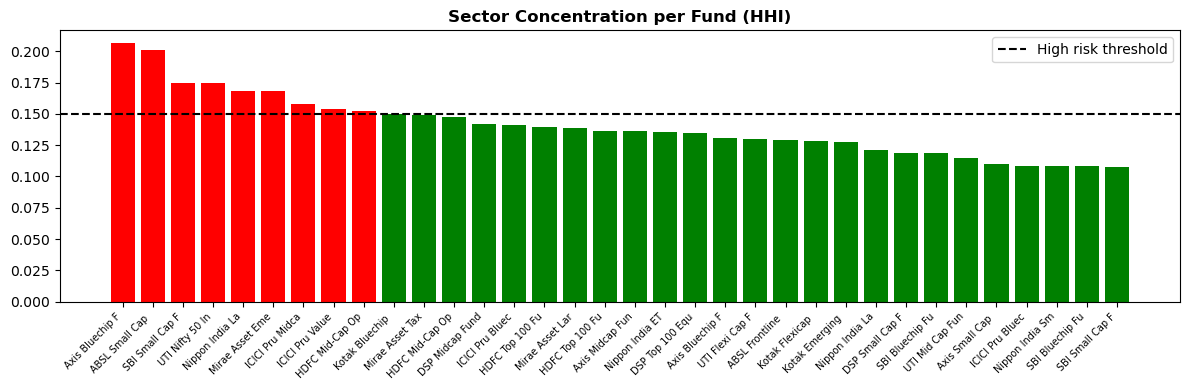

Saved!


In [7]:
#What is HHI? — A score that shows how concentrated a fund is in few sectors. Higher = more risky
hhi_list = []

for code, group in df_hold.groupby("amfi_code"):
    weights = group["weight_pct"] / 100        # convert % to decimal
    hhi     = (weights ** 2).sum()             # sum of squares
    hhi_list.append({"amfi_code": code, "hhi": round(hhi, 4)})

df_hhi = pd.DataFrame(hhi_list)
df_hhi = df_hhi.merge(df_fund[["amfi_code", "scheme_name"]], on="amfi_code")
df_hhi = df_hhi.sort_values("hhi", ascending=False)

print("=== Most Concentrated Funds ===")
print(df_hhi.head(10)[["scheme_name", "hhi"]])

df_hhi.to_csv(PROCESSED / "sector_hhi.csv", index=False)

# Bar chart
plt.figure(figsize=(12, 4))
plt.bar(range(len(df_hhi)), df_hhi["hhi"],
        color=["red" if x > 0.15 else "green" for x in df_hhi["hhi"]])
plt.xticks(range(len(df_hhi)),
           df_hhi["scheme_name"].str[:15],
           rotation=45, ha="right", fontsize=7)
plt.axhline(y=0.15, color="black", linestyle="--", label="High risk threshold")
plt.title("Sector Concentration per Fund (HHI)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(RAW / "sector_hhi_chart.png", dpi=150)
plt.show()
print("Saved!")